[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SwissChardLeaf/icrn/blob/main/docs/tutorials/extending_abstract_reactions.ipynb)
[![View on GitHub](https://img.shields.io/badge/source-GitHub-blue?logo=github)](https://github.com/SwissChardLeaf/icrn/blob/main/docs/tutorials/extending_abstract_reactions.ipynb)

Extending Abstract Reactions
============================

This notebook shows how to implement custom reaction kinetics in icrn by
subclassing [`AbstractReaction`][icrn.AbstractReaction].

Part 1 explains the abstract interface and how reactions plug into the
solver. Part 2 walks through a concrete example: a Michaelis–Menten
enzyme-catalyzed reaction.

In [1]:
!pip install icrn

# Part 1 — The `AbstractReaction` interface

Most examples in this library will utilize mass action kinetics, by using
networks built from [`MassActionReaction`][icrn.MassActionReaction].
For a different rate law (Michaelis–Menten, Hill, etc.), one should extend
[`AbstractReaction`][icrn.AbstractReaction].

Every reaction object stores three pieces of symbolic data:

- **`reactants`** — a [`Complex`][icrn.Complex] describing what is consumed
- **`products`** — a [`Complex`][icrn.Complex] describing what is produced
- **`aux`** — optional subclass-specific data (for mass action this is the
  rate expression)

And to extend the abstract class

## `flux()` — net flux for Euler / RK4

`flux()` returns a **callable** `f(state, non_state)`, not a numeric
dictionary. This is deliberate: building the evaluator can be expensive
(e.g. compiling einsum computations), while evaluation happens on every
integrator sub-step.

At runtime the callable receives:

- **`state`** — current species concentrations, keyed by base [`Species`][icrn.Species]
- **`non_state`** — rate constants and other parameters, keyed by [`RateConstant`][icrn.RateConstant] or [`TensorExpression`][icrn.TensorExpression]

It must return a dictionary `{species: net_flux}` where positive values are
production and negative values are consumption.

Typical usage inside the solver looks like:

```python
flux_f = rxn.flux()              # compile once
net = flux_f(state, non_state)   # evaluate many times
```

## `flux_pd()` — production/destruction split for Patankar integrators

Patankar-type integrators (`reaction_solver="PatankarEuler"`) need each
species' flux split into non-negative **production** and **destruction**
parts. Implement `flux_pd()` the same way: return a callable, not numbers.

```python
pd_f = rxn.flux_pd()
production, destruction = pd_f(state, non_state)
```

Above, both dictionaries map base species to non-negative rates.

If Patankar-type integrators are not of interest, then a dummy
implementation can be provided.

```python
class NewReaction(AbstractReaction):
    def flux_pd(self):
        pass
```

# Part 2 — Michaelis–Menten kinetics

Enzyme-catalyzed conversion of substrate $S$ to product $P$ is often modeled
with the Michaelis–Menten rate law

$$
v = \frac{k_{\mathrm{cat}}\, [E]\, [S]}{K_m + [S]}
$$

where $k_{\mathrm{cat}}$ is the catalytic turnover number, $K_m$ is the
Michaelis constant, and $[E]$ is the free enzyme concentration. Under this
lumped model the enzyme acts as a **catalyst**: it appears in the rate but
is not consumed or produced, so $[E]$ stays constant.

This is **not** mass action, so we implement it as a custom
[`AbstractReaction`][icrn.AbstractReaction].

## Defining `MichaelisMentenReaction`

We are therefore implementing the rule $S \to P$. The rate uses $[E]$ from
`state` and $k_{\mathrm{cat}}$, $K_m$ from `non_state`.

In [6]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

from icrn import (
    AbstractReaction,
    MassActionReaction,
    many_rate_constants,
    many_species,
    solve_well_mixed,
)

In [2]:
class MichaelisMentenReaction(AbstractReaction):
    """Single-substrate enzyme reaction S -> P with Michaelis-Menten kinetics.

    The enzyme E appears in the rate law but is not consumed.
    """

    def flux(self):
        sub, prod, (enz, k_cat_expr, km_expr) = (
            self.reactants,
            self.products,
            self.aux,
        )

        def f(state, non_state):
            data = non_state | state
            # use eval() to get numeric values
            s = sub.eval(data)
            e = enz.eval(data)
            kcat = k_cat_expr.eval(data)
            km = km_expr.eval(data)

            rate = kcat * e * s / (km + s)
            return {sub: -rate, prod: rate}

        return f

    def flux_pd(self):
        sub, prod, (enz, k_cat_expr, km_expr) = (
            self.reactants,
            self.products,
            self.aux,
        )

        def f(state, non_state):
            data = non_state | state
            # use eval() to get numeric values
            s = sub.eval(data)
            e = enz.eval(data)
            kcat = k_cat_expr.eval(data)
            km = km_expr.eval(data)

            rate = kcat * e * s / (km + s)

            production = {sub: 0.0, prod: rate}
            destruction = {sub: rate, prod: 0.0}

            return production, destruction

        return f

Build one reaction and inspect the compiled flux at a single state point:

In [4]:
S, P, E = many_species("S, P, E")
k_cat, K_m = many_rate_constants("k_cat, K_m")

mm_rxn = MichaelisMentenReaction(S, P, (E, k_cat, K_m))

state = {S: jnp.array(1.0), P: jnp.array(0.0), E: jnp.array(0.1)}
non_state = {k_cat: jnp.array(2.0), K_m: jnp.array(0.3)}

mm_rxn.flux()(state, non_state)

{S: Array(-0.15384616, dtype=float32, weak_type=True),
 P: Array(0.15384616, dtype=float32, weak_type=True)}

## Simulation

Custom reactions are passed to the solver exactly like mass-action
reactions. Here we integrate until $t = 5$ with RK4.

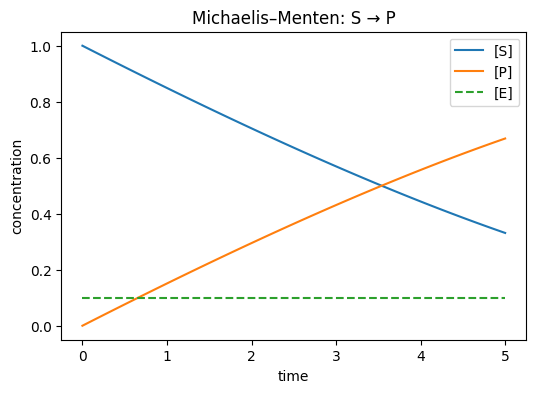

In [14]:
times = jnp.linspace(0.0, 5.0, 101)

traj = solve_well_mixed(
    [mm_rxn],
    conc_vals={S: jnp.array(1.0), P: jnp.array(0.0), E: jnp.array(0.1)},
    rate_constant_vals={k_cat: jnp.array(2.0), K_m: jnp.array(0.3)},
    times=times,
    dt=0.01,
    reaction_solver="RK4",
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(times, traj[S], label="[S]")
ax.plot(times, traj[P], label="[P]")
ax.plot(times, traj[E], label="[E]", linestyle="--")
ax.set_xlabel("time")
ax.set_ylabel("concentration")
ax.legend()
ax.set_title("Michaelis–Menten: S → P")
plt.show()

The new Michaelis-menten reactions will play well with other reaction types,
including mass-action reactions.

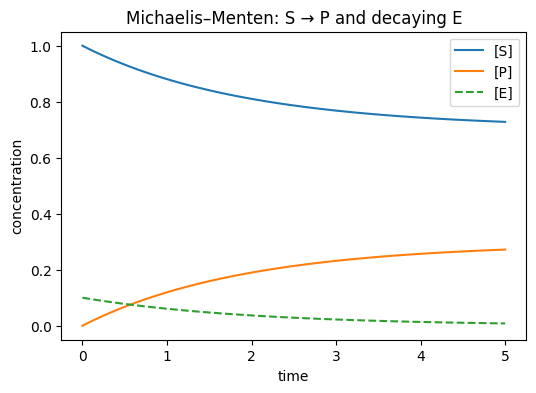

In [16]:
ma_rxn = MassActionReaction(E, 0, 0.5)

traj = solve_well_mixed(
    [mm_rxn, ma_rxn],  # added E decay
    conc_vals={S: jnp.array(1.0), P: jnp.array(0.0), E: jnp.array(0.1)},
    rate_constant_vals={k_cat: jnp.array(2.0), K_m: jnp.array(0.3)},
    times=times,
    dt=0.01,
    reaction_solver="RK4",
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(times, traj[S], label="[S]")
ax.plot(times, traj[P], label="[P]")
ax.plot(times, traj[E], label="[E]", linestyle="--")
ax.set_xlabel("time")
ax.set_ylabel("concentration")
ax.legend()
ax.set_title("Michaelis–Menten: S → P and decaying E")
plt.show()

## Summary

- Extend [`AbstractReaction`][icrn.AbstractReaction] when the rate law is
  not mass action.
- Implement **`flux()`** and **`flux_pd()`** as factories that return
  callables; the solver handles compilation timing and repeated evaluation.
- Use **`object.__setattr__`** in `__init__` to populate fields on the
  frozen base dataclass.
- Drop custom reaction instances into the same [`solve_well_mixed`][icrn.solve_well_mixed]
  / [`solve_reaction_diffusion`][icrn.solve_reaction_diffusion] APIs as
  [`MassActionReaction`][icrn.MassActionReaction].

Possible next steps: add an enzyme–substrate complex explicitly with mass-
action reactions, implement indexed enzyme pools, or combine custom reactions
with mass-action steps in one network.